# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 2.
H = 1.

NGSOLVE = True

lc = 1.

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [2]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

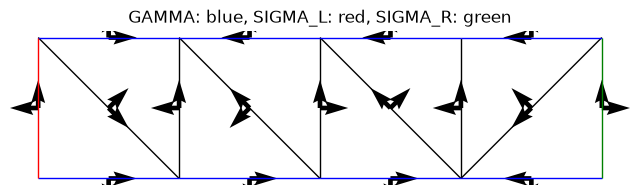

In [3]:
waveguide.plot()

In [4]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [5]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [53]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
mode = Mode(k, H, t=3, direction=PropagationDirection.LEFT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [54]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [55]:
from cases.waveguide.serial_fluxes import NtDLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [56]:
from trefftz.dg.assemblers import SerialNumerics
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, n=n, H=H)},
#                           nonlocal_boundary_kernels={NtDBC: NtD_nonlocal(R=R, d_2=0.5, M=10, H=H)})

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
                          nonlocal_boundary_kernels={})

We should also choose a local basis

In [57]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 21
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

168

and an assembler:

In [58]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [59]:
from trefftz.problem import Problem  # (I don't think "problem" uses "numerics" any more.)
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [60]:
A = P.assemble_LHS()

Interior: 100%|██████████| 7/7 [00:00<00:00,  9.90edge/s]


assembling local operators
region: Gamma


100%|██████████| 8/8 [00:00<00:00, 78.71edge/s]


region: Sigma_L


100%|██████████| 1/1 [00:00<00:00, 93.06edge/s]


region: Sigma_R


100%|██████████| 1/1 [00:00<00:00, 89.14edge/s]

assembling non-local operators


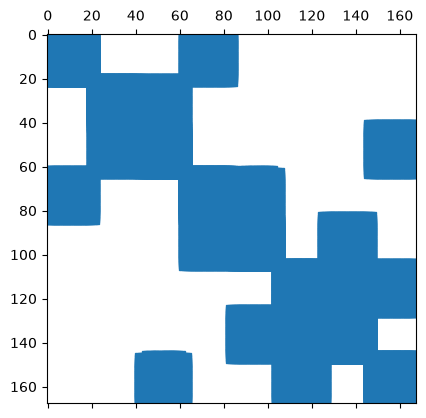

In [61]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [62]:
b = P.assemble_RHS()

In [63]:
P.solve()

In [64]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[ 9.73667731e-01-1.75579978e+00j, -2.82406711e-01+1.32743491e+00j,
        -3.16874011e+00-3.03608051e-01j, -3.79434019e+00-6.79526302e-01j,
        -4.16937122e+00+1.36829958e+00j, -2.95035899e-01+3.91852217e+00j,
         3.71789793e+00+1.01520484e-01j,  1.25307437e+00-5.10059355e+00j,
        -5.06678154e-02-7.80092654e+00j,  6.38801570e+00-3.25692802e+00j,
         4.30420995e-01+2.92880921e+00j, -6.75944064e+00-5.08598565e+00j,
        -9.36634896e+00+4.88950997e+00j, -6.49142486e+00+6.15148858e+00j,
        -3.21722780e+00+1.16212186e+00j,  3.24022168e+00+1.51084481e+00j,
         3.98955685e+00+8.15306426e+00j, -5.12660950e-02+8.02549297e+00j,
        -1.10619117e+00+1.09890307e+00j, -6.45704443e+00-4.14004101e-01j,
         2.84517565e+00+5.29363798e+00j],
       [ 6.85999040e+03-9.58751485e+03j, -4.56174788e+03+8.62306535e+03j,
         5.40172044e+03+3.48577407e+03j,  1.00441837e+04+3.34153183e+03j,
         1.28826040e+04-5.56617827e+02j,  3.42675237e+03-6.33382799e+0

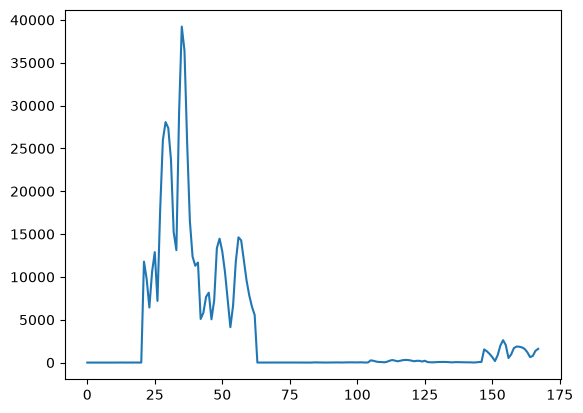

In [65]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [66]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

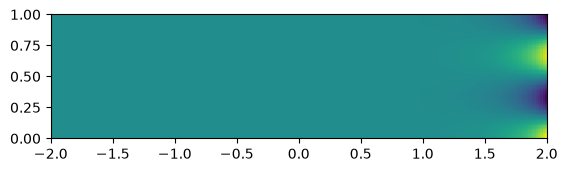

In [67]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])